## This is the code for generating the Influence Score vs. Loss Plot.

By default, if you play this file directly, it will generate the IF and TracIn score vs Samples Loss plot with respect to our experiment result.

**Main Guideline**:  
Read in the Influence lists and Loss lists -> Merge the two lists to have both influence score and loss for each sample -> Plot the influence score vs the Sample Loss -> Add a regression Line inside the plot

**Format**:  
**Input** The Influence lists and loss lists that you read in.  
**Output**  The influence score vs Loss Plot with regression line inserted.

You don't need to change anything else if you only want to produce the Influence Score vs Sample Loss plot. You only need to change the read_csv part to the new data that you generated in the estimation code.

Import Area

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

1. We first read in the Influence Score lists and Loss list.

In [2]:
df_IF = pd.read_csv("IF_Train_Set_1_Adult.csv")
df_TC = pd.read_csv("TC_Train_Set_1_Adult.csv")
df_loss = pd.read_csv("Train_Loss_Train_Set_1_Adult.csv")

2. Then the two lists will be merged on the same training sample.

In [3]:
df = pd.merge(df_IF, df_loss, on="Train_ID", how="inner")
print(df)

       Train_ID     Score       Loss
0         13934  1.107738   1.209688
1         36869  0.504031   0.469162
2         35508  0.456507   1.136354
3         14811  0.454727   0.812376
4          7615  0.442253   1.415343
...         ...       ...        ...
44717      3298 -4.975736   3.420228
44718      6621 -6.779480   9.442087
44719     33503 -7.342255  12.081600
44720      5919 -8.362152  11.317877
44721     14247 -8.648041   8.295872

[44722 rows x 3 columns]


3. Some basic statistics are given here but not really necessary. Just to have a brief look of the data

In [4]:
scores = df["Score"]

print("=== Basic Statistics ===")
print(f"Mean: {np.mean(scores):.6f}")
print(f"Median: {np.median(scores):.6f}")
print(f"Std: {np.std(scores):.6f}")
print(f"Min: {np.min(scores):.6f}")
print(f"Max: {np.max(scores):.6f}")

=== Basic Statistics ===
Mean: 0.012324
Median: 0.069287
Std: 0.216627
Min: -8.648041
Max: 1.107738


In [5]:
total = len(scores)

num_positive = np.sum(scores > 0)
num_negative = np.sum(scores < 0)

print("\n=== Sign Distribution ===")
print(f"Positive: {num_positive} ({num_positive/total*100:.2f}%)")
print(f"Negative: {num_negative} ({num_negative/total*100:.2f}%)")


=== Sign Distribution ===
Positive: 34457 (77.05%)
Negative: 10265 (22.95%)


In [6]:
neg = scores[scores < 0]
pos = scores[scores > 0]

print("Mean |neg|:", np.mean(np.abs(neg)))
print("Mean |pos|:", np.mean(np.abs(pos)))

Mean |neg|: 0.2728395511379979
Mean |pos|: 0.09727626477666647


4. Main plot is produced here, where we plot the Influence Score to the corresponding sample loss.

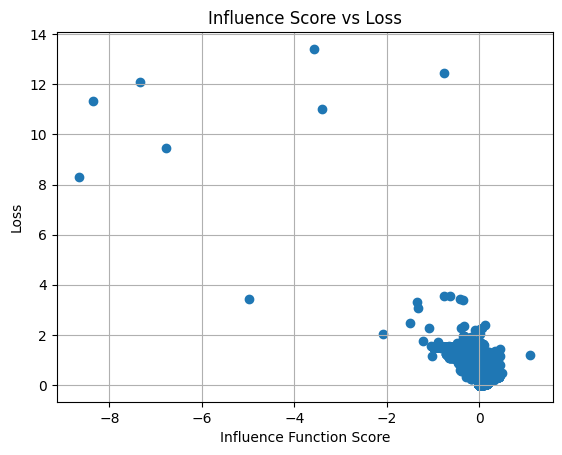

In [7]:
import matplotlib.pyplot as plt

plt.scatter(df["Score"], df["Loss"])
plt.xlabel("Influence Function Score")
plt.ylabel("Loss")
plt.title("Influence Score vs Loss")
plt.grid(True)
plt.show()

5. Then, the regression line for the two data are fit here

In [8]:
X = df["Score"].values.reshape(-1, 1)
y = df["Loss"].values

# Fit model
model = LinearRegression()
model.fit(X, y)

# Predictions
y_pred = model.predict(X)

print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)
print("R^2:", model.score(X, y))

Slope: -1.7955360834431675
Intercept: 0.5172291898138311
R^2: 0.5980758000693356


6. We finally plot the regression line inside the original plot.

In [9]:
# plt.scatter(X, y, alpha=0.6, label="Data")
# plt.plot(X, y_pred, linewidth=2, label="Regression Line",color="red")

# plt.xlabel("Influence Function Score")
# plt.ylabel("Loss")
# plt.title("Influence vs Loss with Regression Fit")
# plt.legend()
# plt.grid(True)
# plt.savefig(
#     "Outliers_Adult_FOIF.png",
#     dpi=600,
#     bbox_inches="tight"
# )
# plt.show()

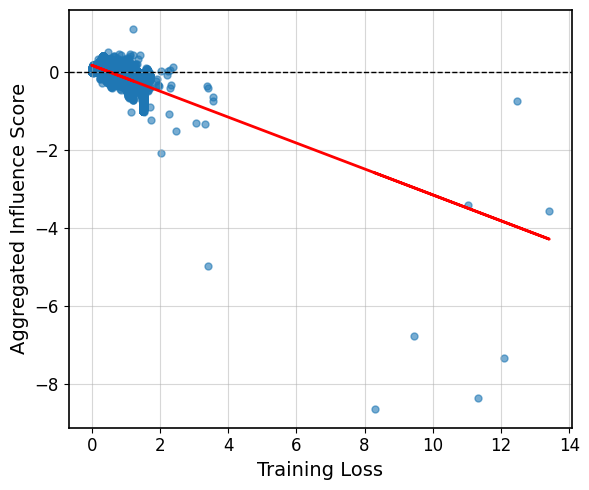

In [10]:
x_loss = y.reshape(-1, 1)          # x-axis: Training loss
y_infl = X.reshape(-1, 1)          # y-axis: Aggregated influence score

reg = LinearRegression()
reg.fit(x_loss, y_infl)
y_pred = reg.predict(x_loss)

plt.figure(figsize=(6, 5))

plt.scatter(x_loss, y_infl, alpha=0.6, s=25)
plt.plot(x_loss, y_pred, linewidth=2, color="red")

# horizontal zero line
plt.axhline(y=0, color="black", linewidth=1, linestyle="--")

# labels with larger font
plt.xlabel("Training Loss", fontsize=14)
plt.ylabel("Aggregated Influence Score", fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# grid
plt.grid(True, alpha=0.5)

# add border / box
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)
    spine.set_color("black")

# remove title and legend
# plt.title(...)
# plt.legend()

plt.savefig(
    "Outliers_Adult_IF_new.png",
    dpi=600,
    bbox_inches="tight"
)


plt.tight_layout()
plt.show()

7. Same procedure happens in the following for the TracIn score and Loss.

In [11]:
df_TCLOSS = pd.merge(df_TC, df_loss, on="Train_ID", how="inner")
print(df_TCLOSS)

       Train_ID     Score       Loss
0          5919  0.111814  11.317877
1         33503  0.110088  12.081600
2         18699  0.107058  13.415754
3          6621  0.104400   9.442087
4         34226  0.103834  11.031629
...         ...       ...        ...
44717     29842 -0.089340   1.529237
44718     32389 -0.091513   1.299780
44719     18988 -0.094232   1.315915
44720     25363 -0.102383   1.363689
44721      7615 -0.111303   1.415343

[44722 rows x 3 columns]


In [12]:
scores = df_TCLOSS["Score"]

print("=== Basic Statistics ===")
print(f"Mean: {np.mean(scores):.6f}")
print(f"Median: {np.median(scores):.6f}")
print(f"Std: {np.std(scores):.6f}")
print(f"Min: {np.min(scores):.6f}")
print(f"Max: {np.max(scores):.6f}")

=== Basic Statistics ===
Mean: 0.003118
Median: 0.023312
Std: 0.040911
Min: -0.111303
Max: 0.111814


In [13]:
total = len(scores)

num_positive = np.sum(scores > 0)
num_negative = np.sum(scores < 0)

print("\n=== Sign Distribution ===")
print(f"Positive: {num_positive} ({num_positive/total*100:.2f}%)")
print(f"Negative: {num_negative} ({num_negative/total*100:.2f}%)")


=== Sign Distribution ===
Positive: 33635 (75.21%)
Negative: 11087 (24.79%)


In [14]:
neg = scores[scores < 0]
pos = scores[scores > 0]

print("Mean |neg|:", np.mean(np.abs(neg)))
print("Mean |pos|:", np.mean(np.abs(pos)))

Mean |neg|: 0.06240455040507826
Mean |pos|: 0.02471568378595894


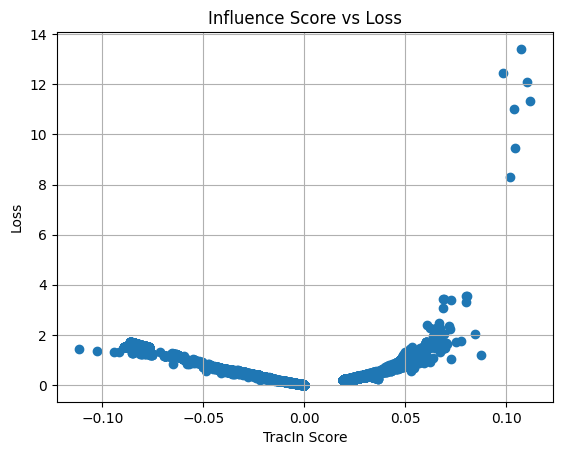

In [15]:
import matplotlib.pyplot as plt

plt.scatter(df_TCLOSS["Score"], df_TCLOSS["Loss"])
plt.xlabel("TracIn Score")
plt.ylabel("Loss")
plt.title("Influence Score vs Loss")
plt.grid(True)
plt.show()

In [16]:
from sklearn.linear_model import LinearRegression
import numpy as np
X = df_TCLOSS["Score"].values.reshape(-1, 1)
y = df_TCLOSS["Loss"].values

# Fit model
model = LinearRegression()
model.fit(X, y)

# Predictions
y_pred = model.predict(X)

print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)
print("R^2:", model.score(X, y))

Slope: -10.396309429687275
Intercept: 0.5275144202705243
R^2: 0.7151152747795807


In [17]:
# plt.scatter(X, y, alpha=0.6, label="Data")
# plt.plot(X, y_pred, linewidth=2, label="Regression Line",color="red")

# plt.xlabel("TracIn Score")
# plt.ylabel("Loss")
# plt.title("Influence vs Loss with Regression Fit")
# plt.legend()
# plt.grid(True)
# plt.savefig(
#     "Outliers_Adult_TC.png",
#     dpi=600,
#     bbox_inches="tight"
# )
# plt.show()

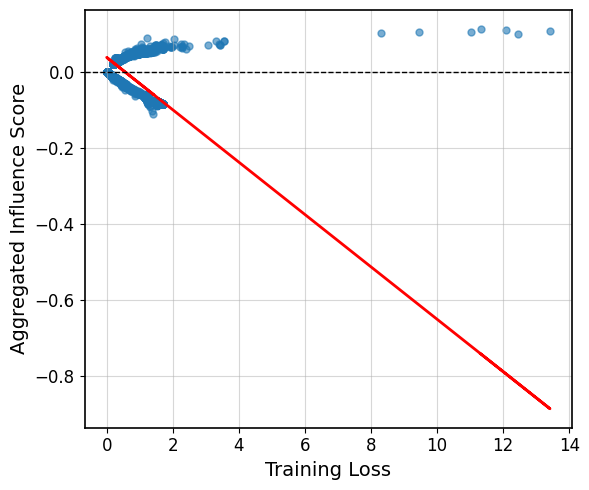

In [18]:
x_loss = y.reshape(-1, 1)          # x-axis: Training loss
y_infl = X.reshape(-1, 1)          # y-axis: Aggregated influence score

reg = LinearRegression()
reg.fit(x_loss, y_infl)
y_pred = reg.predict(x_loss)

plt.figure(figsize=(6, 5))

plt.scatter(x_loss, y_infl, alpha=0.6, s=25)
plt.plot(x_loss, y_pred, linewidth=2, color="red")

# horizontal zero line
plt.axhline(y=0, color="black", linewidth=1, linestyle="--")

# labels with larger font
plt.xlabel("Training Loss", fontsize=14)
plt.ylabel("Aggregated Influence Score", fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# grid
plt.grid(True, alpha=0.5)

# add border / box
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)
    spine.set_color("black")

# remove title and legend
# plt.title(...)
# plt.legend()

plt.savefig(
    "Outliers_Synthetic_TC_new.png",
    dpi=600,
    bbox_inches="tight"
)


plt.tight_layout()
plt.show()